In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
sp = pd.read_csv('spam.csv', encoding='latin-1')
sp.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
sp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
sp.shape

(5572, 5)

In [8]:
sp = sp.iloc[:,:2]
sp.head()
sp.shape

(5572, 2)

In [9]:
sp['v1'] = sp['v1'].replace('ham','Not spam')
sp.head()

,v1,v2
0,Not spam,"Go until jurong point, crazy.. Available only ..."
1,Not spam,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,Not spam,U dun say so early hor... U c already then say...
4,Not spam,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
sp.columns = ['Result','Content']

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
sp['Result'] = le.fit_transform(sp['Result'])
sp.head()

,Result,Content
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [12]:

# keep = first is use for to keep the first value that comes up
sp.drop_duplicates(keep='first', inplace = True)
sp.duplicated().sum()

np.int64(0)

In [13]:
sp['Result'].value_counts()

,count
Result,
0,4516
1,653


<Axes: ylabel='count'>

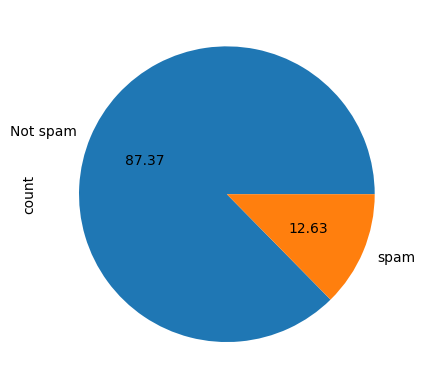

In [14]:
sp['Result'].value_counts().plot(kind = 'pie', labels = ['Not spam','spam'], autopct = "%0.2f")

In [15]:
sp.head()
sp['char_count'] = sp['Content'].apply(lambda x: len(str(x)))
sp['word_count'] = sp['Content'].apply(lambda x: len(str(x).split()))
sp.sample(8)

,Result,Content,char_count,word_count
2240,0,K I'll call you when I'm close,30,7
4595,0,Carlos is down but I have to pick it up from h...,86,21
5549,0,"You know, wot people wear. T shirts, jumpers, ...",87,18
3713,0,"Oh, i will get paid. The most outstanding one ...",159,31
4169,0,"Mmmmmm ... I love you,so much, Ahmad ... I can...",157,32
3550,0,I love you both too :-),23,6
4919,0,"G says you never answer your texts, confirm/deny",48,8
1020,0,Good afternoon on this glorious anniversary da...,224,42


In [16]:

import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [17]:

sp['sent_count'] = sp['Content'].apply(lambda x: len(nltk.sent_tokenize(str(x))))
sp

,Result,Content,char_count,word_count,sent_count
0,0,"Go until jurong point, crazy.. Available only ...",111,20,2
1,0,Ok lar... Joking wif u oni...,29,6,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,2
3,0,U dun say so early hor... U c already then say...,49,11,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,1
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,30,4
5568,0,Will Ì_ b going to esplanade fr home?,37,8,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,10,2
5570,0,The guy did some bitching but I acted like i'd...,125,26,1


In [18]:
sp[sp['Result'] == 0 ][['char_count','word_count','sent_count']].describe()

,char_count,word_count,sent_count
count,4516.000000,4516.000000,4516.000000
mean,70.459256,14.134632,1.820195
std,56.358207,11.116240,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,7.000000,1.000000
50%,52.000000,11.000000,1.000000
75%,90.000000,18.000000,2.000000
max,910.000000,171.000000,38.000000


In [19]:
sp[sp['Result'] == 1 ][['char_count','word_count','sent_count']].describe()

,char_count,word_count,sent_count
count,653.000000,653.000000,653.000000
mean,137.891271,23.681470,2.970904
std,30.137753,5.967672,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,22.000000,2.000000
50%,149.000000,25.000000,3.000000
75%,157.000000,28.000000,4.000000
max,224.000000,35.000000,9.000000


In [20]:
sp.corr(numeric_only=True)['char_count']

,char_count
Result,0.384717
char_count,1.000000
word_count,0.973667
sent_count,0.624139


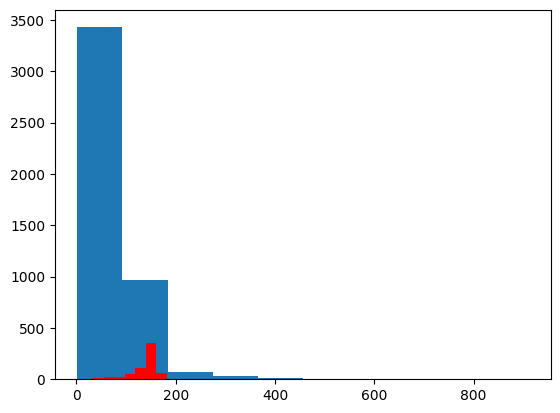

In [21]:
plt.hist(sp[sp['Result'] == 0]['char_count'])
plt.hist(sp[sp['Result'] == 1]['char_count'],color='red')
plt.show()

In [22]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string


nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [23]:
ps = PorterStemmer()

def transform_text(t):
  t = t.lower()

  t = nltk.word_tokenize(t)

  y =[]
  for i in t:
    if i.isalnum() and i not in stopwords.words('english'):
        y.append(i)

  t = y[:]
  y.clear()

  for i in t:
    y.append(ps.stem(i))

  return " ".join(y)

In [24]:
sp['transformed_content'] = sp['Content'].apply( transform_text)

In [25]:
sp.sample(5)

,Result,Content,char_count,word_count,sent_count,transformed_content
1590,0,Somewhr someone is surely made 4 u. And God ha...,148,33,12,somewhr someon sure made 4 god decid perfect t...
463,0,"Sorry, I'll call later ok bye",29,6,1,sorri call later ok bye
1160,0,You sure your neighbors didnt pick it up,40,8,1,sure neighbor didnt pick
3423,1,Am new 2 club & dont fink we met yet Will B gr...,161,30,1,new 2 club dont fink met yet b gr8 2 c u pleas...
4003,0,Well there's a pattern emerging of my friends ...,220,41,1,well pattern emerg friend tell drive come smok...


In [26]:
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer
tfidf = TfidfVectorizer(max_features=3000) #if isko use kiya toh MnB main 100 precision aaya hai
cv = CountVectorizer()   #agar isko use kiya toh Bnb theorem main 98 precision aaya tha

X = tfidf.fit_transform(sp['transformed_content']).toarray()
y = sp['Result'].values


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [28]:
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB
bnb = BernoulliNB()
mnb = MultinomialNB()

In [29]:
mnb.fit(X_train,y_train)

MultinomialNB()

In [30]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score


y_pred = mnb.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(precision_score(y_test, y_pred))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [31]:
com_df = pd.DataFrame({
    'Actual (y_test)': y_test,
    'Predicted (y_pred)': y_pred
})

com_df[com_df['Actual (y_test)']  != com_df['Predicted (y_pred)']].head()

,Actual (y_test),Predicted (y_pred)
5,1,0
19,1,0
32,1,0
44,1,0
45,1,0


In [32]:
bnb.fit(X_train,y_train)

y_pred1 = bnb.predict(X_test)

print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(precision_score(y_test, y_pred1))
# 1. MultinomialNB (The Counter):
# Yeh algorithm counts par focus karta hai. Agar kisi message mein "FREE FREE FREE" 3 baar likha hai, toh yeh sochega
# "Arre baap re, yeh word 3 baar aaya hai, iska weight badha do!" Problem yeh hai ki kabhi-kabhi normal messages mein
# bhi ek word baar-baar aa sakta hai, aur model confuse hokar usko Spam bol deta hai (Yani False Positive badh jata hai aur Precision gir jata hai).
#
# 2. BernoulliNB (The Strict Bouncer - Yes/No):
# Yeh algorithm ginti (counts) ko completely ignore kar deta hai. Iska logic simple hai: 0 ya 1.

# Message mein 'FREE' word hai? -> Yes (1)

# Message mein 'FREE' 10 baar hai? -> Mujhe farq nahi padta, mere liye bas Yes (1) hai.

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [33]:
import pickle

# Apna Vectorizer (TF-IDF ya CountVectorizer) save karo
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))

# Apna train kiya hua Model save karo
pickle.dump(mnb, open('model.pkl', 'wb'))